In [1]:
!pip install pandas scikit-learn matplotlib --break-system-packages

In [45]:
from sklearn import datasets, tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
data = datasets.load_wine()
data.feature_names, data.target_names

(['alcohol',
  'malic_acid',
  'ash',
  'alcalinity_of_ash',
  'magnesium',
  'total_phenols',
  'flavanoids',
  'nonflavanoid_phenols',
  'proanthocyanins',
  'color_intensity',
  'hue',
  'od280/od315_of_diluted_wines',
  'proline'],
 array(['class_0', 'class_1', 'class_2'], dtype='<U7'))

In [15]:
df = pd.DataFrame(columns=data.feature_names, data=data.data)
df["target"] = data.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [16]:
df.target.unique()

array([0, 1, 2])

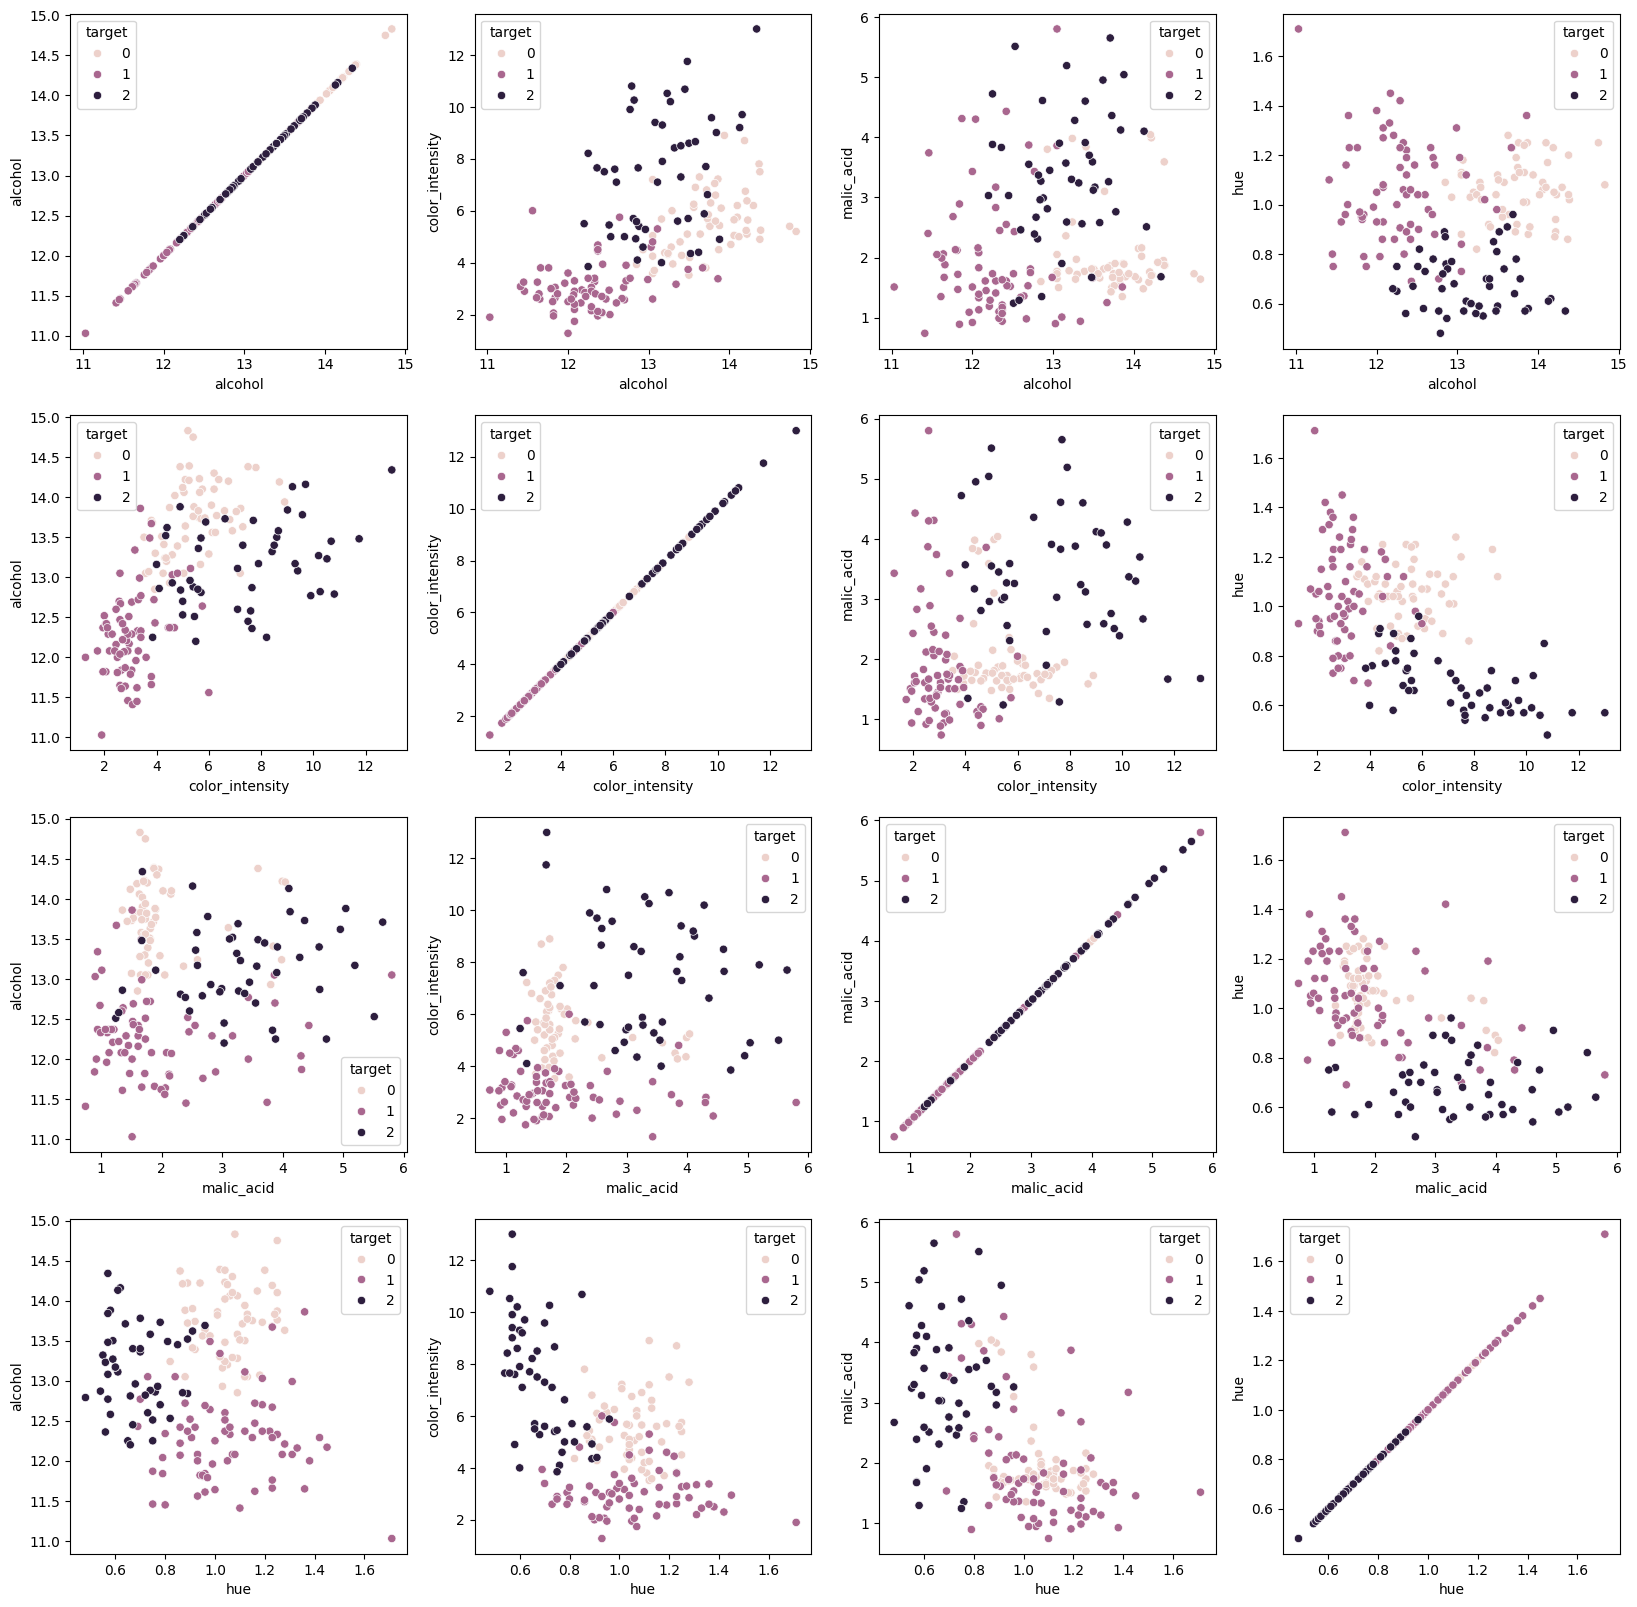

In [28]:
selected_columns = ["alcohol", "color_intensity", "malic_acid", "hue"]
t_columns = len(selected_columns)

fig,ax = plt.subplots(t_columns, t_columns,figsize=(20,20))

for i,row in enumerate(selected_columns):
    for j,col in enumerate(selected_columns):
        sns.scatterplot(data=df, x=row, y=col, hue="target", ax=ax[i,j])

In [55]:
selected_features = ["hue", "alcohol"]

X = df[selected_features]
y = data.target

X_train,X_test,y_train,y_test = train_test_split(X,y)

In [56]:
model = tree.DecisionTreeClassifier()
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


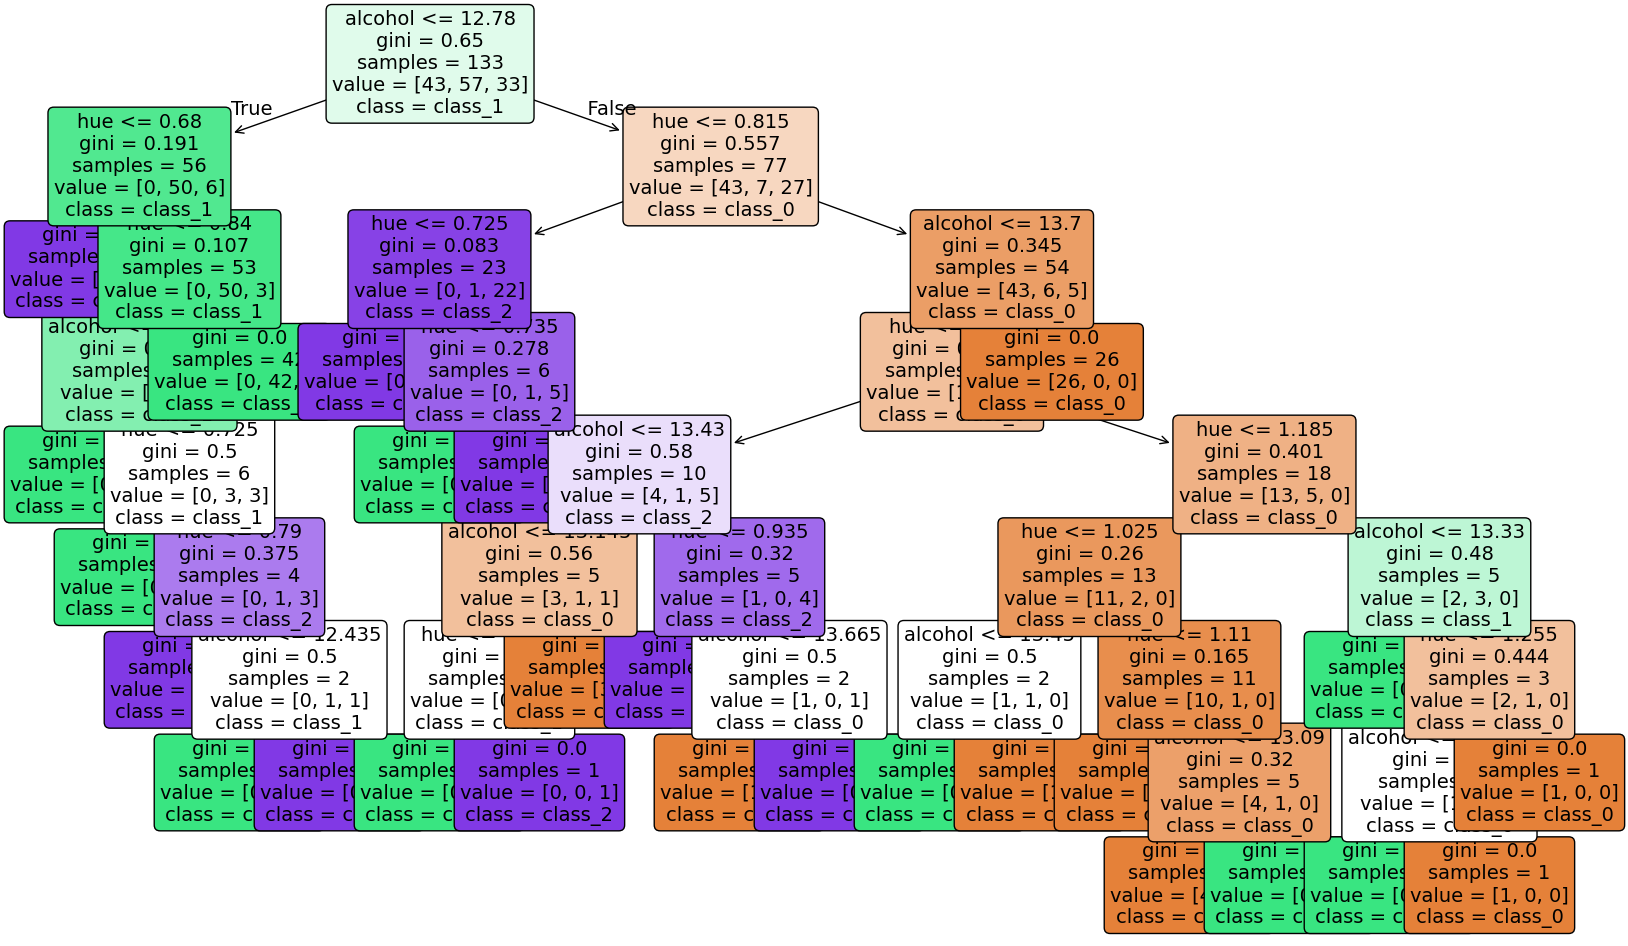

In [57]:
plt.figure(figsize=(20,12))
g = tree.plot_tree(model, 
               feature_names=selected_features, 
               class_names=data.target_names,
                rounded=True, 
               filled=True, 
               fontsize=14
              )

In [58]:
y_pred = model.predict(X_test)

print(f"Acurácia: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Acurácia: 0.8888888888888888
              precision    recall  f1-score   support

           0       0.87      0.81      0.84        16
           1       0.86      0.86      0.86        14
           2       0.94      1.00      0.97        15

    accuracy                           0.89        45
   macro avg       0.89      0.89      0.89        45
weighted avg       0.89      0.89      0.89        45

